In [2]:
import imdlib as imd


start_yr = 2015
end_yr = 2016
variable = 'rain' # other options are ('tmin'/ 'tmax')
file_dir = "/Datastorage/saptarishi.dhanuka_asp25/imdlib_data/raw_imdlib"
data = imd.get_data(variable, start_yr, end_yr, fn_format='yearwise', file_dir=file_dir)

Downloading: rain for year 2015
Downloading: rain for year 2016
Download Successful !!!


In [3]:
data = imd.open_data(variable, start_yr, end_yr, 'yearwise', file_dir+'/rain/')
data

In [4]:
ds = data.get_xarray()
ds

<xarray.Dataset> Size: 102MB
Dimensions:  (time: 731, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 6kB 2015-01-01 2015-01-02 ... 2016-12-31
Data variables:
    rain     (time, lat, lon) float64 102MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-04 05:19:13.315926 Python
    references:   
    comment:      
    crs:          epsg:4326

In [5]:
ds_july2015 = ds.sel(time=slice('2015-07-01', '2015-07-31'))
ds_july2015

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 31, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 248B 2015-07-01 2015-07-02 ... 2015-07-31
Data variables:
    rain     (time, lat, lon) float64 4MB -999.0 -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-04 05:19:13.315926 Python
    references:   
    comment:      
    crs:          epsg:4326

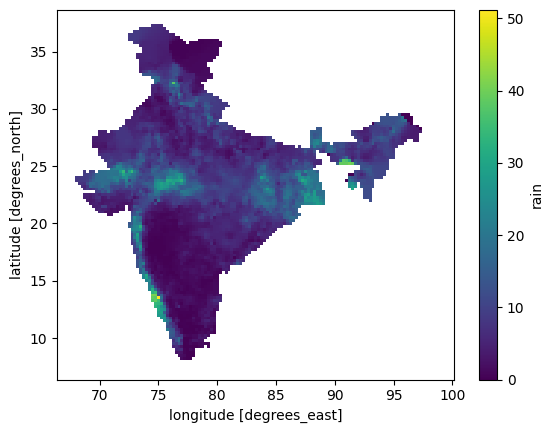

In [7]:
ds_clean = ds_july2015.where(ds_july2015['rain'] != -999.) #Remove NaN values
ds_clean['rain'].mean('time').plot()

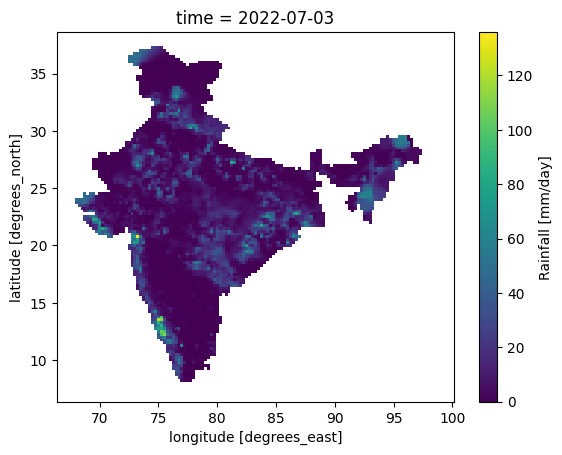

In [38]:
ds_july2022['rain'].isel(time=2).plot()

In [ ]:
# in the xarray check whether all the values in the rain variable are -999

False

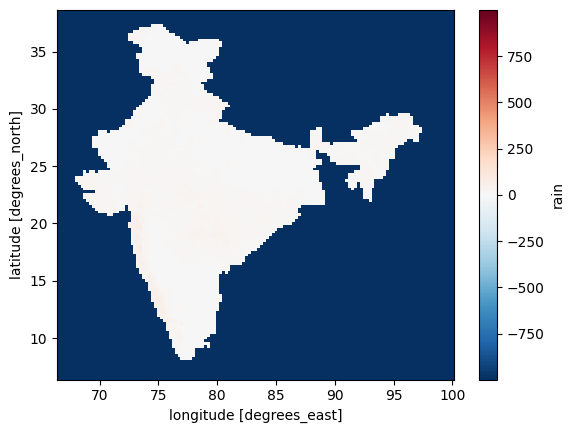

In [11]:
ds['rain'].mean('time').plot()